# P1: Red Neuronal (Teacher) para Clasificación de ECG
*(Clasificación Binaria: Normal vs. Anómalo)*

**PyCon Colombia 2026 🇨🇴 - Workshop | hls4ml: From Python Models to Hardware Acceleration**  
*Versión para Google Colab*

---

El objetivo de este *notebook* es diseñar y entrenar una red neuronal base (modelo "*Teacher*") capaz de clasificar latidos cardíacos. Este modelo será nuestro punto de partida para las siguientes etapas de compresión y síntesis hacia hardware (FPGA).

### Resumen de los Datos
Utilizaremos los registros de la **PTB Diagnostic ECG Database** (vía Kaggle):
* **Formato de entrada:** 187 puntos por latido.
* **Escala:** Amplitud normalizada entre 0 y 1.

> ⚠️ **Nota sobre la ejecución en Google Colab:**  
> Cada *notebook* en Colab corre en una máquina virtual independiente. Como el entorno no conserva los archivos de la etapa de preparación (P0), las primeras celdas de este *script* ejecutarán una descarga y partición exprés del dataset (omitiendo la exploración visual) para poder iniciar el entrenamiento.

---

### Referencias

El diseño, compresión y metodología de despliegue en SoC/FPGA que implementaremos a continuación están fundamentados en el siguiente trabajo:

* **[IEEE]** R. S. Molina et al., "An End-to-End Workflow to Efficiently Compress and Deploy DNN Classifiers on SoC/FPGA," *IEEE Embedded Systems Letters*, vol. 16, no. 3, 2024.

Instalación de librerías (específico de Colab): `qkeras` y `tensorflow-model-optimization` no vienen preinstaladas. **Importante:** QKeras puede requerir fijar la versión de TensorFlow — si ves errores de compatibilidad al importar, avisa para ajustar versiones antes del taller.

In [ ]:
# ============================================================
# Setup P1: Preparación del entorno
# ============================================================

import os
from IPython.display import clear_output
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sn

print("Preparando el entorno...")
# 1. Clonar el repositorio
if not os.path.exists("hls4ml_workshop"):
    !git clone -q https://github.com/GICM-UdeA/hls4ml_workshop.git

# 2. Acceder al directorio del proyecto
os.chdir("hls4ml_workshop")

# 4. Instalación de dependencias para entrenamiento y síntesis HLS
print("Instalando dependencias del entorno.")

!pip install -q tensorflow==2.12.0 keras==2.12.0 qkeras==0.9.0 tensorflow-model-optimization==0.8.0


print("Entorno preparado correctamente.")
print("Directorio actual del kernel:")
print(os.getcwd())

In [ ]:
#Forzamos el reinicio del entorno de ejecución
os.kill(os.getpid(), 9)

In [ ]:
#Verificamos las versiones de Tensorflow y Keras
import tensorflow as tf
import keras

print("TensorFlow:", tf.__version__)
print("Keras:", keras.__version__)

---

## 1.) Preparación de datos y stack de entrenamiento 
(Versión condensada de *P0_Dataset_PTB.ipynb*)

1. **Carga y etiquetado:** Importa los latidos normales (Clase `0`) y anómalos (Clase `1`).
2. **Partición (Train/Test):** Reserva exactamente 1,000 muestras de cada clase para el set de prueba (estrictamente balanceado).
3. **Mezcla:** Concatena y baraja (*shuffle*) los datos para evitar sesgos durante el entrenamiento de la red.

In [38]:
# ============================================================
# Preparación de datos
# ============================================================

print("Cargando y procesando el dataset...")

data_dir = Path('./dataset')
LABEL_COL = 187

# 1. Carga de datos crudos
raw_normal   = pd.read_csv(data_dir / 'ptbdb_normal.csv', header=None)
raw_abnormal = pd.read_csv(data_dir / 'ptbdb_abnormal.csv', header=None)

# 2. Extracción de características y asignación de etiquetas
normal_vect   = raw_normal.iloc[:, :LABEL_COL].values.astype(np.float32)
abnormal_vect = raw_abnormal.iloc[:, :LABEL_COL].values.astype(np.float32)

df_normal_full = pd.DataFrame(normal_vect)
df_normal_full['class'] = 0

df_abnormal_full = pd.DataFrame(abnormal_vect)
df_abnormal_full['class'] = 1

# 3. Partición balanceada para Prueba (Test)
n_samples = min(1000, len(df_normal_full), len(df_abnormal_full))

test_normal   = df_normal_full.sample(n=n_samples, random_state=45)
test_abnormal = df_abnormal_full.sample(n=n_samples, random_state=45)

train_normal   = df_normal_full.drop(test_normal.index)
train_abnormal = df_abnormal_full.drop(test_abnormal.index)

# 4. Concatenación y mezcla aleatoria (Shuffle)
test_df  = pd.concat([test_normal, test_abnormal]).sample(frac=1, random_state=42).reset_index(drop=True)
train_df = pd.concat([train_normal, train_abnormal]).sample(frac=1, random_state=42).reset_index(drop=True)

# 5. Exportación
test_df.to_csv(data_dir / "test_dataset.csv", index=False)
train_df.to_csv(data_dir / "train_dataset.csv", index=False)

print("Dataset preparado y exportado correctamente:")
print(f"   - Entrenamiento : {train_df.shape[0]} muestras {train_df.shape}")
print(f"   - Prueba (Test) : {test_df.shape[0]} muestras {test_df.shape}")

Cargando y procesando el dataset...
Dataset preparado y exportado correctamente:
   - Entrenamiento : 12552 muestras (12552, 188)
   - Prueba (Test) : 2000 muestras (2000, 188)


### 1.1.) Balanceo y Formato para Keras/TensorFlow

Antes de alimentar la red neuronal, necesitamos ajustar los datos a los requerimientos del modelo:
1. **Balanceo de Clases:** En PTB, hay muchos más casos anómalos que normales. Haremos un submuestreo (*undersampling*) de la clase mayoritaria para evitar que la red se sesgue.
2. **One-Hot Encoding:** Convertimos las etiquetas de un solo número (`0` o `1`) a vectores binarios (`[1, 0]` y `[0, 1]`). Esto es necesario para la capa de salida y la función de pérdida de nuestra red.
3. **Set de Validación:** Separamos el 30% de los datos de entrenamiento para monitorear el sobreajuste (*overfitting*) durante el proceso.

In [39]:
# ============================================================
# Carga y preparación de datos para el modelo de ML
# ============================================================

from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical

print("Preparando matrices para TensorFlow...")

# 1. Cargar conjuntos de datos procesados
df_train = pd.read_csv("./dataset/train_dataset.csv")
df_test  = pd.read_csv("./dataset/test_dataset.csv")

# 2. Balancear las clases del conjunto de entrenamiento (Undersampling)
df_normal = df_train[df_train["class"] == 0]
df_abnormal = df_train[df_train["class"] == 1].sample(n=len(df_normal), random_state=42)

df_train_balanced = pd.concat([df_normal, df_abnormal]).sample(frac=1, random_state=42)

# 3. Separar características (X) y etiquetas (y)
X_train_full = df_train_balanced.drop(columns=["class"]).values.astype(np.float32)
y_train_full = df_train_balanced["class"].values

X_test = df_test.drop(columns=["class"]).values.astype(np.float32)
y_test = df_test["class"].values

# 4. Conversión de etiquetas a One-Hot Encoding
# Clase 0 -> [1, 0] | Clase 1 -> [0, 1]
y_train_full = to_categorical(y_train_full, num_classes=2)
y_test = to_categorical(y_test, num_classes=2)

# 5. División en Entrenamiento y Validación (70% - 30%)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full,
    y_train_full,
    test_size=0.3,
    random_state=42
)

# ============================================================
# Resumen de Dimensiones
# ============================================================
print("Datos preparados correctamente. Dimensiones finales:\n")
print(f"   - Entrenamiento : X {X_train.shape} | y {y_train.shape}")
print(f"   - Validación    : X {X_val.shape}   | y {y_val.shape}")
print(f"   - Prueba (Test) : X {X_test.shape}  | y {y_test.shape}")

Preparando matrices para TensorFlow...
Datos preparados correctamente. Dimensiones finales:

   - Entrenamiento : X (4264, 187) | y (4264, 2)
   - Validación    : X (1828, 187)   | y (1828, 2)
   - Prueba (Test) : X (2000, 187)  | y (2000, 2)


### 1.2.) Librerías de entrenamiento y optimización (pipeline ML)

**Importante:** `src.distillationClassKeras` contiene la clase `Distiller` que se usa más abajo para Knowledge Distillation. esta se llama desde el directorio `./src` dentro del repositorio clonado del proyecto `hls4ml_workshop`

In [40]:
from numpy import array

# Tensorflow and Keras imports
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.models import *
from tensorflow.keras.layers import *
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam, SGD
from tensorflow.keras.regularizers import l2, l1

import tensorflow_model_optimization as tfmot

# Prunning API
from tensorflow_model_optimization.python.core.sparsity.keras import prune, pruning_schedule, pruning_callbacks
from tensorflow_model_optimization.sparsity.keras import strip_pruning

# Quantization API
from qkeras import *

# Knowledge Distillation
from src.distillationClassKeras import *  #./src/distillationClassKeras.py

# Metrics
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.utils import shuffle

# Pre-processing
from sklearn.preprocessing import MinMaxScaler, StandardScaler, LabelEncoder

# Training utils
from sklearn.model_selection import train_test_split

tf.random.set_seed(42)
np.random.seed(42)

### 1.3.) Declaración de Funciones auxiliares

Definición de funciones auxiliares para el preprocesamiento del dataset, automatiza la mezcla (*shuffle*) y separación de datos en los sets de entrenamiento y prueba.
 
> En códigos heredados u otros proyectos, es común realizar la normalización de los datos (por ejemplo dividir entre 512). **Aqui NO debes realizar normalización** El dataset PTB Diagnostic EGC de Kaggle ya viene pre-normalizado en un rango de `[0, 1]`. Si vuelves a dividir, aplastarás la señal a valores cercanos a cero y la red neuronal no aprenderá nada.

In [41]:
# ============================================================
# Declaración de Funciones Auxiliares
# ============================================================

def preproc_dataset(df_abnormal, df_normal, train_size=2000, test_size=500, seed=42):
    """
    Mezcla, balancea y divide el dataset en conjuntos de entrenamiento y prueba.
    NOTA: Se omite la normalización porque los datos ya vienen en rango [0, 1].
    """
    # 1. Mezcla inicial reproducible
    df_abnormal = shuffle(df_abnormal, random_state=seed)
    df_normal   = shuffle(df_normal, random_state=seed)

    # 2. Ajuste dinámico del tamaño de entrenamiento
    # (En PTB, 'Normal' suele ser la clase limitante tras divisiones previas)
    max_available = min(len(df_abnormal), len(df_normal)) - test_size
    
    if train_size > max_available:
        print(f"⚠️ Ajustando train_size de {train_size} a {max_available} (Máximo disponible por clase).")
        train_size = max_available

    # 3. Selección de muestras (tamaños iguales para mantener el balance)
    train_abnormal = df_abnormal.iloc[:train_size]
    test_abnormal  = df_abnormal.iloc[train_size : train_size + test_size]

    train_normal = df_normal.iloc[:train_size]
    test_normal  = df_normal.iloc[train_size : train_size + test_size]

    # 4. Combinación de ambas clases
    df_train = pd.concat([train_abnormal, train_normal])
    df_test  = pd.concat([test_abnormal, test_normal])

    # 5. Mezcla final (Shuffle) y reseteo de índices
    df_train = shuffle(df_train, random_state=seed).reset_index(drop=True)
    df_test  = shuffle(df_test, random_state=seed).reset_index(drop=True)

    # ---------- Normalización ----------
    # PTB ya viene en [0,1] desde Kaggle -> NO se re-normaliza aquí.
    # (En proyectos anteriores como EJ-299-33 se dividía entre 512.0)

    return df_train, df_test

### 1.4.) Carga y preprocesamiento del Dataset

In [42]:
data_dir = Path("./dataset")
train_file = data_dir / "train_dataset.csv"
test_file  = data_dir / "test_dataset.csv"

# Cargar datasets
df_train = pd.read_csv(train_file)
df_test  = pd.read_csv(test_file)

# Separar clases del set de entrenamiento 
# (Convención PTB: 0 = Normal, 1 = Anómalo)
df_normal   = df_train[df_train["class"] == 0]
df_abnormal = df_train[df_train["class"] == 1]

# Resumen visual
print("Datos cargados correctamente:")
print(f"   - Train Normal (Clase 0)  : {len(df_normal)} muestras")
print(f"   - Train Anómalo (Clase 1) : {len(df_abnormal)} muestras")
print(f"   - Test Set (Prueba)       : {len(df_test)} muestras")

Datos cargados correctamente:
   - Train Normal (Clase 0)  : 3046 muestras
   - Train Anómalo (Clase 1) : 9506 muestras
   - Test Set (Prueba)       : 2000 muestras


In [43]:
# Preprocesamiento del dataset para entrenamiento
df_train, dfTest = preproc_dataset(df_abnormal, df_normal)

# Separar la etiqueta de clase de las características
df_train_ = df_train.pop('class')
dfTest_   = dfTest.pop('class')

# Codificación One-Hot de las etiquetas
le = LabelEncoder()
y = le.fit_transform(df_train_)
y = to_categorical(y, 2)

le = LabelEncoder()
yTest = le.fit_transform(dfTest_)
yTest = to_categorical(yTest, 2)

# División del dataset de entrenamiento en entrenamiento y validación
x_train, x_val, y_train, y_val = train_test_split(df_train, y, test_size=0.3, random_state=42)

# Conversión de datos al formato float32 requerido por TensorFlow
x_train = x_train.astype(np.float32)
x_val   = x_val.astype(np.float32)

print(f"x_train: {x_train.shape} | x_val: {x_val.shape} | dfTest: {dfTest.shape}")

x_train: (2800, 187) | x_val: (1200, 187) | dfTest: (1000, 187)


---

## 2.) Entrenamiento y Optimización del Modelo de ML

En esta etapa se entrena el modelo y se aplican técnicas de optimización orientadas a reducir el costo computacional y facilitar su implementación en arquitecturas de hardware de recursos limitados.

Los procesos aplicados son:

- **Poda (Pruning)**: Técnica que reduce la complejidad del modelo eliminando pesos con baja contribución durante el aprendizaje, generando modelos más pequeños y eficientes.

- **Cuantización (Quantization)**: Proceso de reducción de la precisión numérica de los parámetros y operaciones del modelo. Por ejemplo, permite representar pesos originalmente en formato de punto flotante de 32 bits (`float32`) utilizando representaciones de menor precisión como enteros de 8 bits (`int8`), reduciendo memoria y costo computacional.

- **Entrenamiento consciente de cuantización (Quantization Aware Training, QAT)**: Técnica que incorpora la simulación de la cuantización durante el entrenamiento, permitiendo que el modelo se adapte a la pérdida de precisión introducida por el uso de datos y pesos de menor resolución.

- **Knowledge Distillation**: Técnica donde un modelo compacto (estudiante *Student*) aprende del comportamiento de un modelo más grande (maestro *Teacher*), utilizando sus predicciones para obtener un modelo reducido con un desempeño similar.

### 2.1.) Entrenamiento del Modelo Teacher

In [44]:
# Definición de hiperparámetros del modelo maestro (Teacher)
# Arquitectura basada en EJ-299-33. Se modifica únicamente la dimensión
# de entrada (161 -> 187 características), manteniendo la misma topología.

lr = 0.0001
neurons_teacher = [10, 5, 7, 5, 6]

La siguiente función define la arquitectura del **modelo maestro (Teacher)**, compuesto por seis capas densas completamente conectadas.

**Cambio respecto a EJ-299-33:** se modifica únicamente la dimensión de entrada, pasando de 161 a **187 características**, correspondiente a la longitud fija de cada latido del dataset PTB. La topología interna de la red se mantiene sin modificaciones y la capa de salida continúa realizando clasificación binaria mediante `Dense(2)`.

In [45]:
N_INPUT = 187   # EJ-299-33 usaba 161

def teacher_topology(bestHp):

    teacher = keras.Sequential(
        [
            keras.Input(shape=(N_INPUT, )),
            Dense(bestHp[0], name='fc1', input_shape=(N_INPUT,), kernel_regularizer=l2(0.001),),
            Activation(activation='relu', name='relu1'),

            Dense(bestHp[1], name='fc2', kernel_regularizer=l2(0.001),),
            Activation(activation='relu', name='relu2'),

            Dense(bestHp[2], name='fc3', kernel_regularizer=l2(0.001),),
            Activation(activation='relu', name='relu3'),
            Dropout(0.1),

            Dense(bestHp[3], name='fc4', kernel_regularizer=l2(0.001),),
            Activation(activation='relu', name='relu4'),
            Dropout(0.2),

            Dense(bestHp[4], name='fc5'),
            Activation(activation='relu', name='relu5'),
            Dropout(0.2),

            Dense(2, name='output'),
            Activation('softmax', name='activationOutput'),
        ],
        name='teacher_MLP',
    )

    teacher.summary()

    return teacher

### 2.2.) Construcción del modelo Teacher

Sin cambios respecto al original: arquitectura definida en `teacher_topology()`, optimizador **Adam**, pérdida `binary_crossentropy`.

In [46]:
def build_teacher(neurons_teacher):
    model = teacher_topology(neurons_teacher)
    opt = Adam(lr)
    model.compile(optimizer=opt, loss='binary_crossentropy', metrics=['accuracy'])
    return model

In [47]:
teacher_model = build_teacher(neurons_teacher)

Model: "teacher_MLP"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 fc1 (Dense)                 (None, 10)                1880      
                                                                 
 relu1 (Activation)          (None, 10)                0         
                                                                 
 fc2 (Dense)                 (None, 5)                 55        
                                                                 
 relu2 (Activation)          (None, 5)                 0         
                                                                 
 fc3 (Dense)                 (None, 7)                 42        
                                                                 
 relu3 (Activation)          (None, 7)                 0         
                                                                 
 dropout_3 (Dropout)         (None, 7)                 

### 2.3.) Entrenamiento

En esta etapa se realiza el entrenamiento del modelo maestro (**Teacher**). Debido al tamaño reducido de la arquitectura y al número de muestras disponible (~2000-3000 muestras por clase), se espera una convergencia rápida durante el entrenamiento, incluso utilizando los recursos computacionales disponibles en Google Colab (GPU/CPU).

In [48]:
callbacks = [
    # Detiene el entrenamiento si la pérdida de validación no mejora
    # y recupera los mejores pesos obtenidos.
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=2,
        verbose=1,
        restore_best_weights=True
    ),

    # Reduce la tasa de aprendizaje cuando la métrica de validación
    # deja de mejorar, favoreciendo la convergencia del modelo.
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.4,
        patience=3,
        verbose=1
    )
]

# Entrenamiento del modelo Teacher
history_teacher = teacher_model.fit(
    x=x_train,
    y=y_train,
    validation_data=(x_val, y_val),
    batch_size=64,
    epochs=200,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/200
44/44 [==============================] - 1s 5ms/step - loss: 0.7285 - accuracy: 0.5025 - val_loss: 0.7284 - val_accuracy: 0.4867 - lr: 1.0000e-04
Epoch 2/200
44/44 [==============================] - 0s 2ms/step - loss: 0.7283 - accuracy: 0.4904 - val_loss: 0.7273 - val_accuracy: 0.4867 - lr: 1.0000e-04
Epoch 3/200
44/44 [==============================] - 0s 2ms/step - loss: 0.7258 - accuracy: 0.5029 - val_loss: 0.7262 - val_accuracy: 0.4867 - lr: 1.0000e-04
Epoch 4/200
44/44 [==============================] - 0s 2ms/step - loss: 0.7260 - accuracy: 0.4789 - val_loss: 0.7250 - val_accuracy: 0.4867 - lr: 1.0000e-04
Epoch 5/200
44/44 [==============================] - 0s 2ms/step - loss: 0.7241 - accuracy: 0.4721 - val_loss: 0.7239 - val_accuracy: 0.4867 - lr: 1.0000e-04
Epoch 6/200
44/44 [==============================] - 0s 2ms/step - loss: 0.7230 - accuracy: 0.4754 - val_loss: 0.7226 - val_accuracy: 0.4867 - lr: 1.0000e-04
Epoch 7/200
44/44 [==============================] -

### 2.4.) Evaluación del entrenamiento

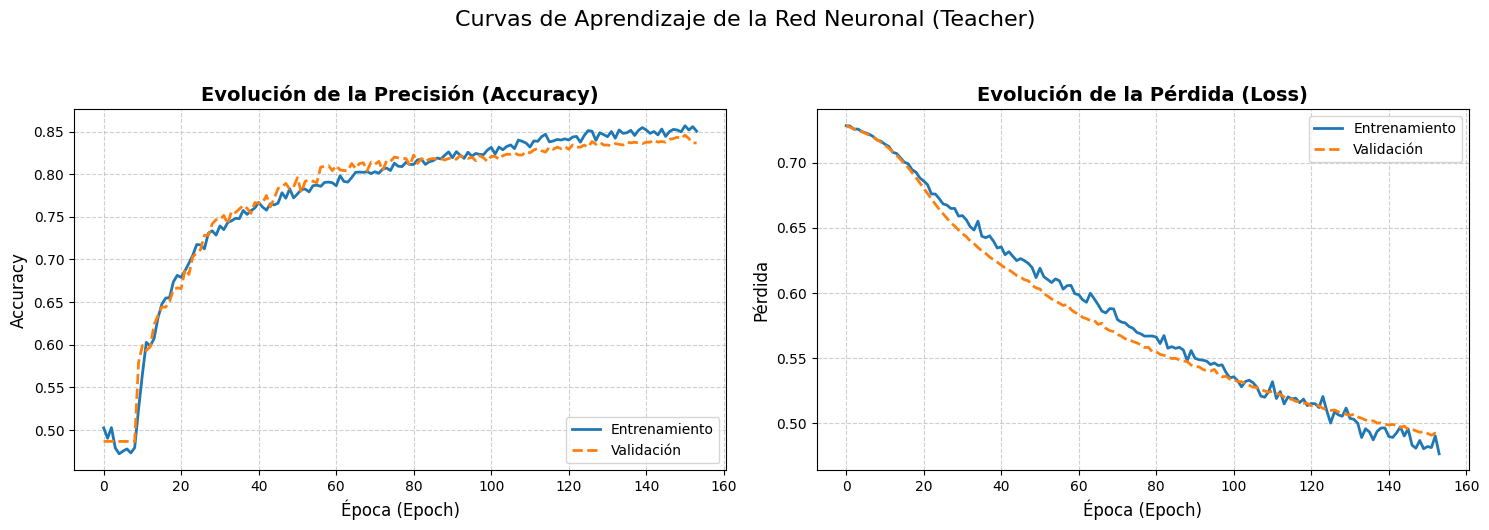

In [49]:

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(15, 5))

# --- Gráfica 1: Precisión (Accuracy) ---
axes[0].plot(history_teacher.history['accuracy'], label='Entrenamiento', linewidth=2, color='#1f77b4')
axes[0].plot(history_teacher.history['val_accuracy'], label='Validación', linewidth=2, color='#ff7f0e', linestyle='--')
axes[0].set_title('Evolución de la Precisión (Accuracy)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Accuracy', fontsize=12)
axes[0].set_xlabel('Época (Epoch)', fontsize=12)
axes[0].legend(loc='lower right')
axes[0].grid(True, linestyle='--', alpha=0.6)

# --- Gráfica 2: Pérdida (Loss) ---
axes[1].plot(history_teacher.history['loss'], label='Entrenamiento', linewidth=2, color='#1f77b4')
axes[1].plot(history_teacher.history['val_loss'], label='Validación', linewidth=2, color='#ff7f0e', linestyle='--')
axes[1].set_title('Evolución de la Pérdida (Loss)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Pérdida', fontsize=12)
axes[1].set_xlabel('Época (Epoch)', fontsize=12)
axes[1].legend(loc='upper right')
axes[1].grid(True, linestyle='--', alpha=0.6)

fig.suptitle('Curvas de Aprendizaje de la Red Neuronal (Teacher)', fontsize=16, y=1.05)
plt.tight_layout()
plt.show()

Medimos el rendimiento mediante la matriz de confusión

32/32 [==============================] - 0s 543us/step


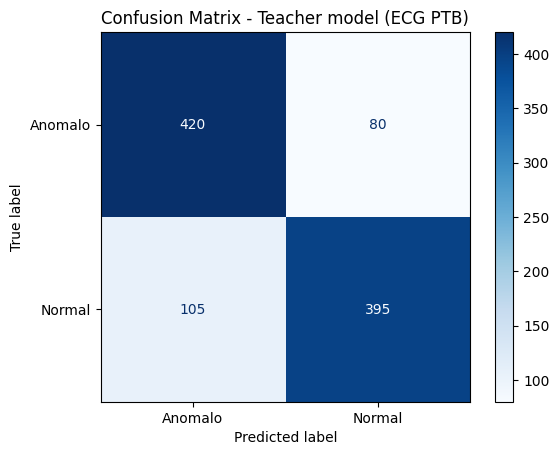

In [50]:
# Obtain the confusion matrix using the testing dataset
y_pred_probs = teacher_model.predict(dfTest)
y_pred = np.argmax(y_pred_probs, axis=1)

y_true = np.argmax(yTest, axis=1)

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Anomalo', 'Normal'])
disp.plot(cmap="Blues")
plt.title('Confusion Matrix - Teacher model (ECG PTB)')
plt.show()

**Hasta aquí ya se ha logrado un entrenamiento satisfactorio de la red neuronal**

### 2.5.) Guardado del modelo Teacher

Una vez que estamos satisfechos con el rendimiento de nuestra red neuronal, debemos exportarla. Este archivo será nuestro punto de partida para los pasos siguientes.

>  **¡Advertencia!**
> El modelo se guardará en el almacenamiento temporal de esta máquina virtual. Si cierras la pestaña o la sesión caduca, **el archivo se perderá**. Asegúrate de descargar el archivo generado (`teacher_model.h5`) a tu computadora local dando clic derecho en el panel de archivos de la izquierda.

In [51]:
os.makedirs('models', exist_ok=True)
teacher_model.save('models/teacherModel_ECG_PTB.h5')

# Descargar el modelo a tu computador (opcional, util mientras pruebas)
#from google.colab import files
#files.download('models/teacherModel_ECG_PTB.h5')

# Alternativa: guardarlo directamente en Drive si lo montaste
# teacher_model.save('/content/drive/MyDrive/taller-ecg-fpga/models/teacherModel_ECG_PTB.h5')

---
**Siguiente paso:**

*P2_NN_Pruning_ECG.ipynb* Aplicar **Pruning** y **Quantization Aware Training (QAT)** sobre el modelo Teacher para construir el modelo Student.